# EJERCICIO 2


### Paso 1: Importación de Librerías y Carga de Imagen
Primero, importamos las herramientas necesarias: OpenCV para el tratamiento de imagen, NumPy para el manejo de matrices, Matplotlib para visualizar y sklearn



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Definimos la ruta de la imagen
path = '/content/StarryNight.jpg'
img = cv2.imread(path)

if img is None:
    print("Error: No se encontró la imagen. Súbela al panel de archivos de la izquierda.")
else:
    # Convertimos de BGR a RGB para que los colores sean correctos
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("Imagen cargada con éxito.")

Imagen cargada con éxito.


### Paso 2: Preprocesamiento de Datos
El algoritmo K-Means requiere que los datos estén en una lista de puntos que son los píxeles y no en una cuadrícula. Además, redimensionamos la imagen para que el cálculo sea más rápido sin perder la esencia del color.

In [ ]:
# Redimensionamos a 100x100 píxeles para optimizar el tiempo de procesamiento
img_small = cv2.resize(img_rgb, (100, 100))

# Convertimos la matriz 2D de la imagen (100x100x3) en una lista plana (10000x3)
pixel_vals = img_small.reshape((-1, 3))

# Convertimos a float32 ya que KMeans realiza cálculos de distancia de alta precisión
pixel_vals = np.float32(pixel_vals)

###Paso 3: Aplicación de K-Means y Visualización Comparativa
Iteramos sobre los valores de $k$ solicitados ($2, 4$ y $6$). En cada paso, el algoritmo encuentra los colores promedio, o centroides y asigna cada píxel al color más cercano.

Colores promedio (Centros RGB) para K=2:
[[ 38  48  69]
 [110 130 147]]

Colores promedio (Centros RGB) para K=4:
[[ 92 118 149]
 [ 53  70 112]
 [155 167 148]
 [ 30  35  40]]

Colores promedio (Centros RGB) para K=6:
[[ 46  59  87]
 [102 127 154]
 [159 172 161]
 [ 27  31  34]
 [153 151  84]
 [ 64  87 134]]



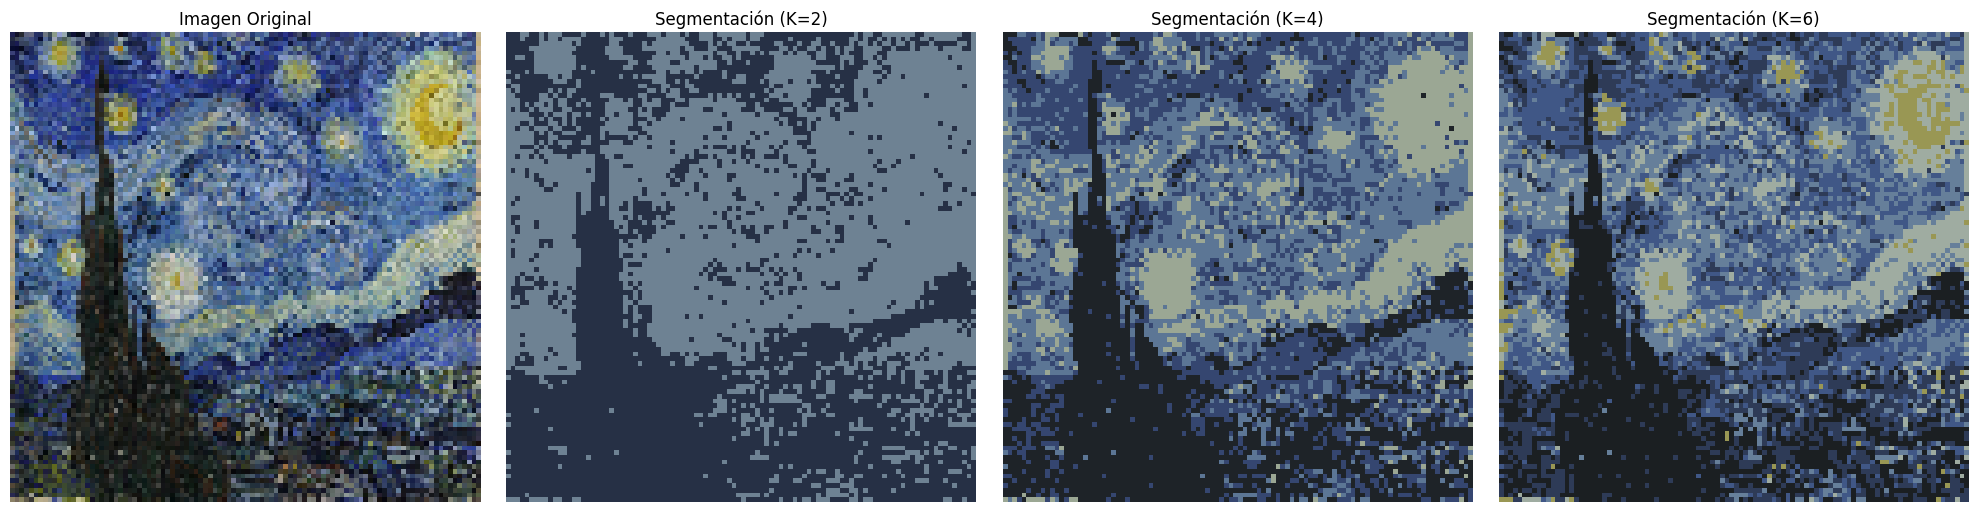

In [ ]:
# Definimos los valores de K a evaluar
ks = [2, 4, 6]

# Preparamos el lienzo para mostrar 4 imágenes (Original + 3 niveles de K)
plt.figure(figsize=(20, 5))

# Mostramos la imagen original como referencia
plt.subplot(1, 4, 1)
plt.imshow(img_small)
plt.title('Imagen Original')
plt.axis('off')

# Bucle para ejecutar el algoritmo por cada K
for i, k in enumerate(ks):
    # Inicializamos el modelo KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixel_vals)

    # Obtenemos las etiquetas de cada píxel y los centros (colores promedio)
    labels = kmeans.labels_
    centers = np.uint8(kmeans.cluster_centers_)

    # Reconstruimos la imagen reemplazando cada píxel por su color de clúster
    segmented_data = centers[labels.flatten()]
    segmented_img = segmented_data.reshape(img_small.shape)

    # Mostramos el resultado en el subplot correspondiente
    plt.subplot(1, 4, i + 2)
    plt.imshow(segmented_img)
    plt.title(f'Segmentación (K={k})')
    plt.axis('off')

    # Imprimimos los centros numéricos (Requisito del ejercicio)
    print(f"Colores promedio (Centros RGB) para K={k}:\n{centers}\n")

plt.tight_layout()
plt.show()